# 虚假新闻检测任务

本 Notebook 按要求完成数据准备、数据质量检查、深度预处理、TF-IDF + 文体特征工程、逻辑回归与校准 LinearSVC 对比评估，并输出所有图表。

说明：本 Notebook 已改为使用相对路径读取 `true.csv` 和 `fake.csv`。请把 notebook、两个 CSV 文件和 `run_fake_news_detection.py` 放在同一目录下运行。


In [1]:
import json
import re
import string
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Image
from nltk.stem import PorterStemmer
from scipy.sparse import csr_matrix, hstack
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# 使用相对路径，要求 true.csv、fake.csv 与本 notebook 位于同一目录。
DATA_DIR = Path(".")
TRUE_PATH = DATA_DIR / "data" / "true.csv"
FAKE_PATH = DATA_DIR / "data" / "fake.csv"

# 输出目录也使用相对路径，便于整体移动项目文件夹。
OUTPUT_DIR = Path("outputs") / "fake_news_detection"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 固定随机种子，保证洗牌、划分和模型训练过程可复现。
RANDOM_STATE = 42

# 统一图表主题。
sns.set_theme(style="whitegrid", font_scale=1.05)


In [2]:
import sys
import sklearn
import nltk

print(f"Python 版本: {sys.version}")
print(f"{'套件名称':<15} | {'版本号'}")
print("-" * 30)
print(f"{'Scikit-learn':<15} | {sklearn.__version__}")
print(f"{'NLTK':<15} | {nltk.__version__}")
print(f"{'Pandas':<15} | {pd.__version__}")
print(f"{'NumPy':<15} | {np.__version__}")
print(f"{'Matplotlib':<15} | {plt.matplotlib.__version__}")
print(f"{'Seaborn':<15} | {sns.__version__}")


Python 版本: 3.12.6 (v3.12.6:a4a2d2b0d85, Sep  6 2024, 16:08:03) [Clang 13.0.0 (clang-1300.0.29.30)]
套件名称            | 版本号
------------------------------
Scikit-learn    | 1.6.1
NLTK            | 3.9.1
Pandas          | 2.2.3
NumPy           | 2.1.3
Matplotlib      | 3.9.2
Seaborn         | 0.13.2


## 1. 数据准备

本节读取 `true.csv` 和 `fake.csv`，为真实新闻添加 `target=1`，为虚假新闻添加 `target=0`。随后合并两份数据，并使用固定随机种子进行全局洗牌，保证每次运行结果可复现。


In [3]:
# 分别读取真实新闻和虚假新闻数据。
true_df = pd.read_csv(TRUE_PATH)
fake_df = pd.read_csv(FAKE_PATH)

# 构造监督学习标签：真实新闻为 1，虚假新闻为 0。
true_df["target"] = 1
fake_df["target"] = 0

# 合并数据并全局洗牌，避免原始文件顺序影响训练/测试划分。
df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# 合并标题和正文。标题提供主题与情绪入口，正文提供完整语义信息。
df["combined_text"] = df["title"].fillna("").astype(str) + " " + df["text"].fillna("").astype(str)

display(df.head())
display(df["target"].value_counts().sort_index().rename(index={0: "fake", 1: "true"}))


,title,text,subject,date,target,combined_text
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0,BREAKING: GOP Chairman Grassley Has Had Enoug...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0,Failed GOP Candidates Remembered In Hilarious...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0,Mike Pence’s New DC Neighbors Are HILARIOUSLY...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1,California AG pledges to defend birth control ...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0,AZ RANCHERS Living On US-Mexico Border Destroy...


target
fake    23481
true    21417
Name: count, dtype: int64

## 2. 数据质量检查与可视化

本节检查缺失值和重复样本，并绘制标签分布图与文本长度 KDE 图。数据质量检查用于确认输入数据是否完整，图表则帮助观察真假新闻在样本数量和文本长度上的差异。


,missing_count
title,0.0
text,0.0
subject,0.0
date,0.0
target,0.0
combined_text,0.0
duplicate_title_text_rows,5793.0


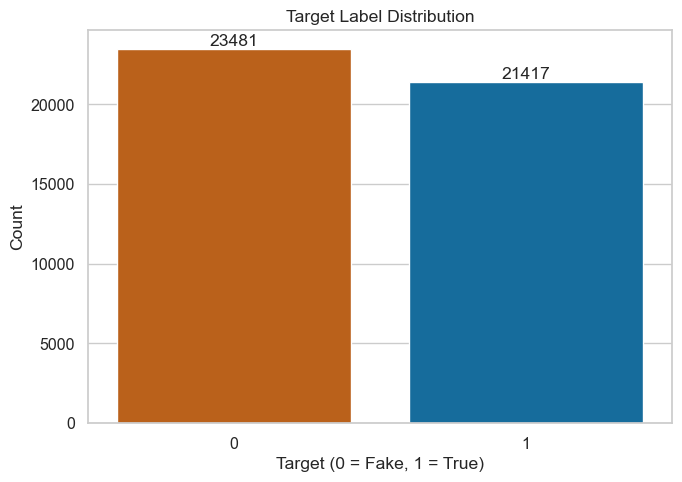

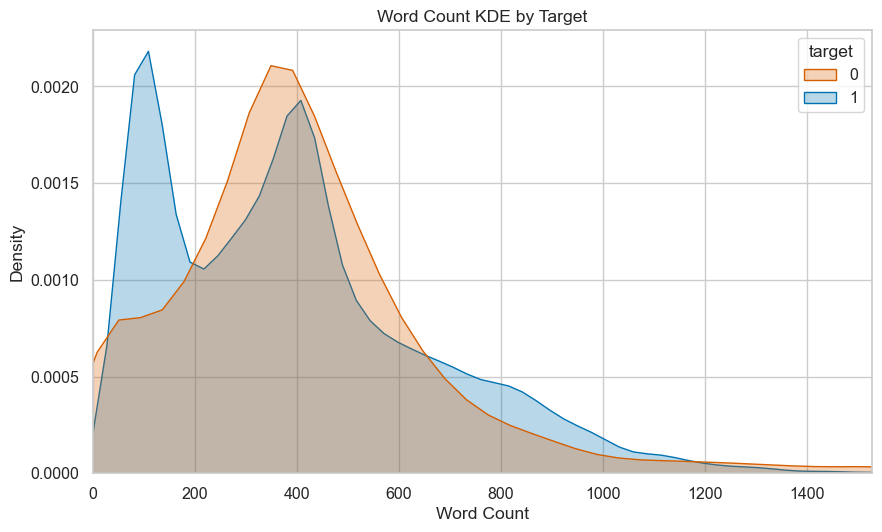

In [4]:
# 统计每个字段的缺失值。
missing_values = df.isna().sum().rename("missing_count").to_frame()

# 按 title 和 text 完全相同的口径统计重复样本。
duplicate_count = int(df.duplicated(subset=["title", "text"]).sum())
quality = missing_values.copy()
quality.loc["duplicate_title_text_rows", "missing_count"] = duplicate_count
quality.to_csv(OUTPUT_DIR / "data_quality_summary.csv")
display(quality)

# 计算新闻文本词数，用于比较真假新闻篇幅分布。
df["word_count"] = df["combined_text"].str.split().str.len()

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="target", hue="target", palette={0: "#D55E00", 1: "#0072B2"}, legend=False)
ax.set_title("Target Label Distribution")
ax.set_xlabel("Target (0 = Fake, 1 = True)")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5.5))
ax = sns.kdeplot(data=df, x="word_count", hue="target", common_norm=False, fill=True, alpha=0.28, palette={0: "#D55E00", 1: "#0072B2"})
ax.set_xlim(0, df["word_count"].quantile(0.99))
ax.set_title("Word Count KDE by Target")
ax.set_xlabel("Word Count")
ax.set_ylabel("Density")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "word_count_kde.png", dpi=180, bbox_inches="tight")
plt.show()


## 3. 深度预处理与特征工程

本节先在清洗前提取文体特征，再进行文本清洗和 TF-IDF 向量化。这样既能保留大写词、感叹号等风格信息，也能把新闻正文转化为模型可学习的数值特征。


In [5]:
# 去除新闻开头的 Reuters 等机构前缀，避免模型把来源标志当作真假判断捷径。
def remove_news_prefix(text):
    text = str(text)
    patterns = [
        r"^\s*[A-Z][A-Z\s.,\'-]{2,80}\s+\(Reuters\)\s*[-—]\s*",
        r"^\s*\([Rr]euters\)\s*[-—]\s*",
        r"^\s*[A-Z][A-Za-z\s.,\'-]{2,80}\s+\(Reuters\)\s*[-—]\s*",
    ]
    for pattern in patterns:
        text = re.sub(pattern, "", text, count=1)
    return text

# PorterStemmer 用于词干提取，停用词使用 scikit-learn 内置英文停用词表。
stemmer = PorterStemmer()
stop_words = set(ENGLISH_STOP_WORDS)
punct_digit_re = re.compile(r"[^A-Za-z\s]+")

# 文体特征 1：大写单词比例。
def caps_ratio(text):
    words = re.findall(r"\b[A-Za-z]+\b", str(text))
    if not words:
        return 0.0
    caps = sum(1 for word in words if len(word) > 1 and word.isupper())
    return caps / len(words)

# 文体特征 2：感叹号频率。
def excl_ratio(text):
    text = str(text)
    words = re.findall(r"\b\w+\b", text)
    return text.count("!") / max(len(words), 1)

# 文本清洗：去前缀、去标点数字、小写化、停用词过滤、词干提取。
def clean_text(text):
    text = remove_news_prefix(text)
    text = punct_digit_re.sub(" ", text)
    tokens = [
        stemmer.stem(token)
        for token in text.lower().split()
        if token not in stop_words and len(token) > 1
    ]
    return " ".join(tokens)

# 必须在清洗前提取文体特征，否则大小写和感叹号会在清洗中丢失。
df["caps_ratio"] = df["combined_text"].map(caps_ratio)
df["excl_ratio"] = df["combined_text"].map(excl_ratio)
df["clean_text"] = df["combined_text"].map(clean_text)
display(df[["target", "word_count", "caps_ratio", "excl_ratio", "clean_text"]].head())


,target,word_count,caps_ratio,excl_ratio,clean_text
0,0,372,0.013193,0.000000,break gop chairman grassley demand trump jr te...
1,0,504,0.013699,0.001946,fail gop candid rememb hilari mock eulog video...
2,0,393,0.034483,0.000000,mike penc new dc neighbor hilari troll homopho...
3,1,97,0.030612,0.000000,california attorney gener xavier becerra said ...
4,0,157,0.031056,0.000000,az rancher live mexico border destroy nanci pe...


In [6]:
# 先划分训练集和测试集，再拟合向量器和标准化器，避免测试集信息提前进入训练过程。
X_train_text, X_test_text, y_train, y_test, train_idx, test_idx = train_test_split(
    df["clean_text"], df["target"], df.index,
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["target"]
)

# TF-IDF 将清洗文本转换为高维稀疏词项特征。
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# 文体特征是连续数值变量，需要标准化后再拼接。
scaler = StandardScaler()
style_cols = ["caps_ratio", "excl_ratio"]
X_train_style = scaler.fit_transform(df.loc[train_idx, style_cols])
X_test_style = scaler.transform(df.loc[test_idx, style_cols])

# 水平拼接 TF-IDF 特征与文体特征，得到最终模型输入。
X_train = hstack([X_train_tfidf, csr_matrix(X_train_style)])
X_test = hstack([X_test_tfidf, csr_matrix(X_test_style)])
X_train.shape, X_test.shape


((35918, 5002), (8980, 5002))

## 4. 模型对比与评估

本节训练逻辑回归和校准后的 LinearSVC，并输出分类报告、混淆矩阵和 ROC 曲线。逻辑回归作为基线模型，LinearSVC作为挑战模型，两者使用相同训练集和测试集，便于公平比较。



Logistic Regression
              precision    recall  f1-score   support

           0     0.9884    0.9832    0.9858      4696
           1     0.9817    0.9874    0.9845      4284

    accuracy                         0.9852      8980
   macro avg     0.9851    0.9853    0.9852      8980
weighted avg     0.9852    0.9852    0.9852      8980



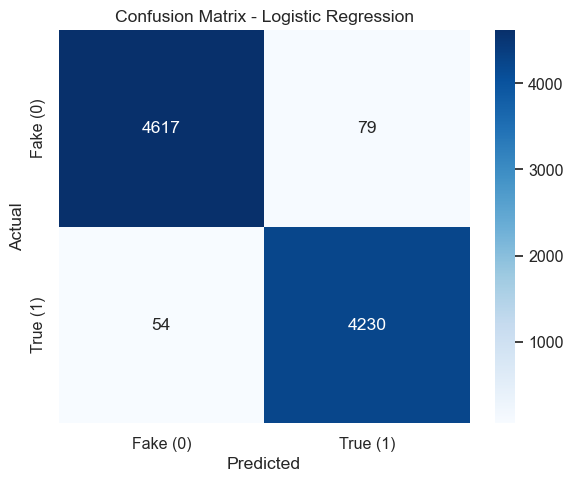


Calibrated LinearSVC
              precision    recall  f1-score   support

           0     0.9919    0.9906    0.9913      4696
           1     0.9897    0.9911    0.9904      4284

    accuracy                         0.9909      8980
   macro avg     0.9908    0.9909    0.9908      8980
weighted avg     0.9909    0.9909    0.9909      8980



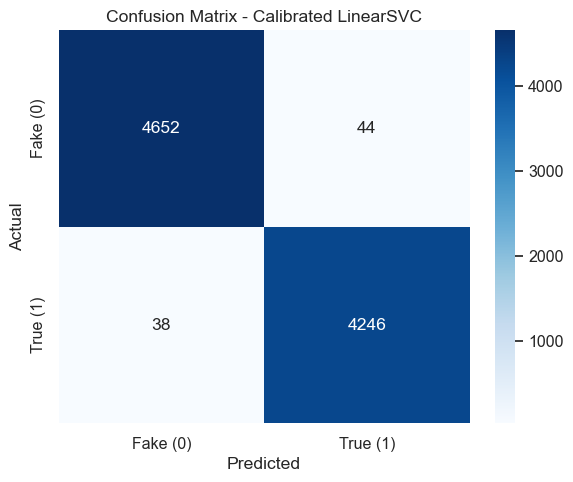

In [7]:
# 逻辑回归作为基线模型，校准 LinearSVC 作为挑战模型。
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=1),
    "Calibrated LinearSVC": CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE), method="sigmoid", cv=3),
}

reports = {}
roc_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name}\n" + "=" * len(name))
    print(classification_report(y_test, pred, digits=4))
    reports[name] = classification_report(y_test, pred, output_dict=True, digits=4)
    with open(OUTPUT_DIR / f"{name.lower().replace(' ', '_')}_classification_report.txt", "w") as f:
        f.write(classification_report(y_test, pred, digits=4))

    # 混淆矩阵用于查看真假新闻分别被如何误判。
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake (0)", "True (1)"], yticklabels=["Fake (0)", "True (1)"])
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"confusion_matrix_{name.lower().replace(' ', '_')}.png", dpi=180, bbox_inches="tight")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    roc_rows.append((name, fpr, tpr, auc))


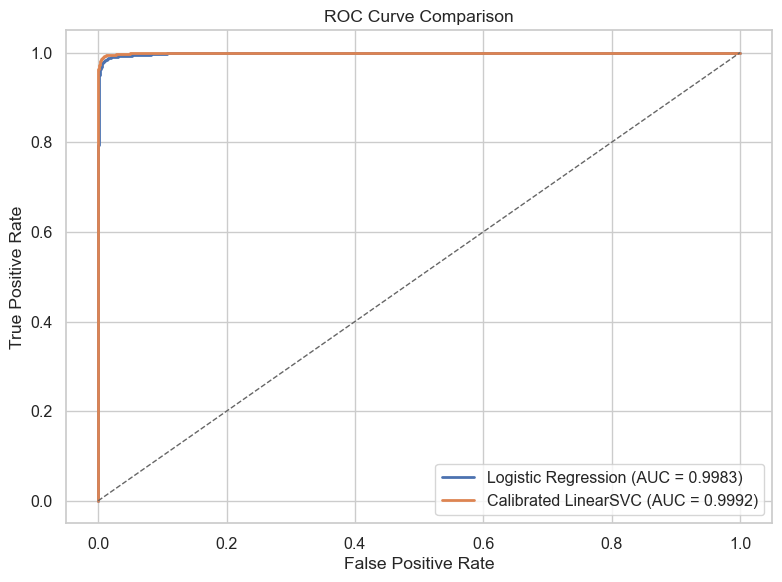

,model,accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.985189,0.985162,0.985191
1,Calibrated LinearSVC,0.990869,0.990850,0.990869


In [8]:
# ROC 曲线比较两个模型在不同阈值下的整体区分能力。
plt.figure(figsize=(8, 6))
for name, fpr, tpr, auc in roc_rows:
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="#666666", linewidth=1)
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

# 汇总核心指标，便于报告引用。
metrics = []
for name, report in reports.items():
    metrics.append({"model": name, "accuracy": report["accuracy"], "macro_f1": report["macro avg"]["f1-score"], "weighted_f1": report["weighted avg"]["f1-score"]})
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(OUTPUT_DIR / "model_metrics_summary.csv", index=False)
display(metrics_df)
